DATA ACQUISITION & PREPROCESSING

In [112]:
# Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [113]:
# Load MNIST Dataset
mnist = tf.keras.datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Each image:28 × 28 grayscale / pixels

In [114]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


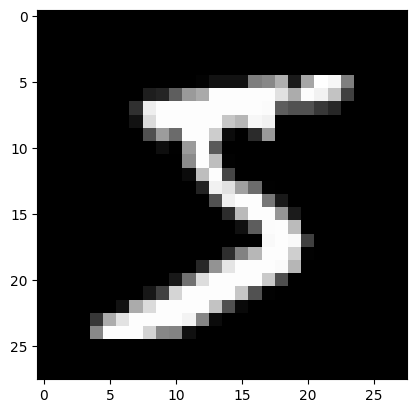

In [115]:
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [116]:
print(y_train[0])

5


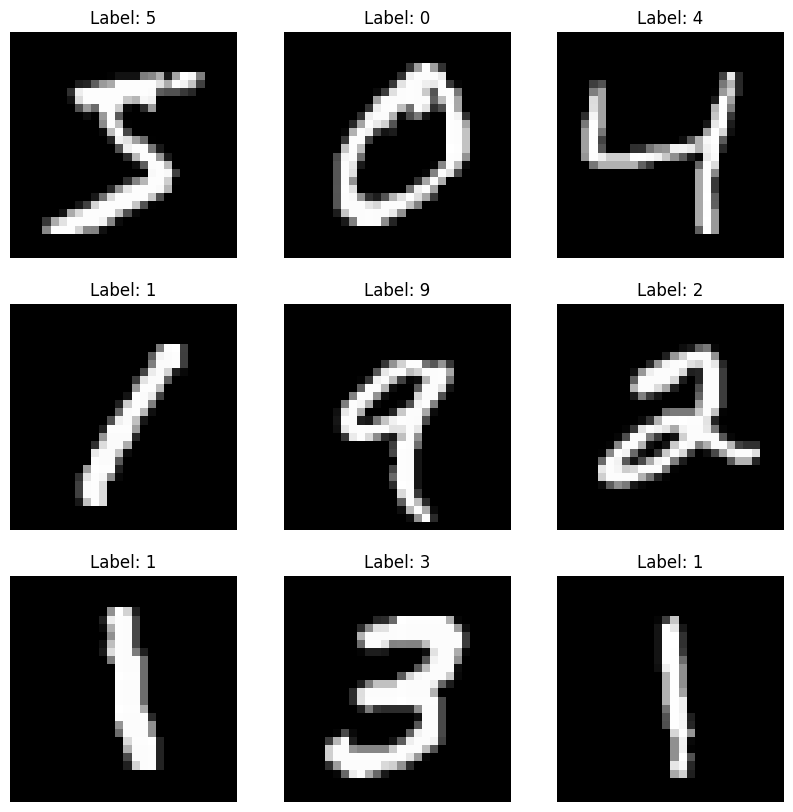

In [117]:
# Display Multiple Digits
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(f"Label: {y_train[i]}")

    plt.axis('off')

plt.show()

In [118]:
# NORMALIZATION
X_train = X_train / 255.0

X_test = X_test / 255.0

In [119]:
print(X_train[0].max())
print(X_train[0].min())

1.0
0.0


In [120]:
# FLATTENING => 28 x 28 = 784
X_train = X_train.reshape(60000, 784)

X_test = X_test.reshape(10000, 784)

print(X_train.shape)

print(X_test.shape)


(60000, 784)
(10000, 784)


## ANN ARCHITECTURE & TRAINING

In [121]:
# Import Keras Components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

# INPUT LAYER + FIRST HIDDEN LAYER
model.add(Dense(
    128,
    activation='relu',
    input_shape=(784,)
))

model.add(Dropout(0.2))

# SECOND HIDDEN LAYER
model.add(Dense(
    64,
    activation='relu'
))

model.add(Dropout(0.2))

# OUTPUT LAYER
model.add(Dense(
    10,
    activation='softmax'
))

d:\ML\Resume_Analyzer_using_ANN\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [122]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [123]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8939 - loss: 0.3549 - val_accuracy: 0.9672 - val_loss: 0.1186
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9485 - loss: 0.1698 - val_accuracy: 0.9718 - val_loss: 0.0891
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9595 - loss: 0.1309 - val_accuracy: 0.9715 - val_loss: 0.0881
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9675 - loss: 0.1093 - val_accuracy: 0.9743 - val_loss: 0.0852
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9703 - loss: 0.0946 - val_accuracy: 0.9785 - val_loss: 0.0710
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9724 - loss: 0.0854 - val_accuracy: 0.9800 - val_loss: 0.0679
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9750 - loss: 0.0783 - val_accuracy: 0.9797 - val_loss: 0.0673
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9763 - loss: 0.0737 -

EVALUATION & MODEL EXPORT

In [124]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9769 - loss: 0.0838
Test Loss: 0.0837835893034935
Test Accuracy: 0.9768999814987183


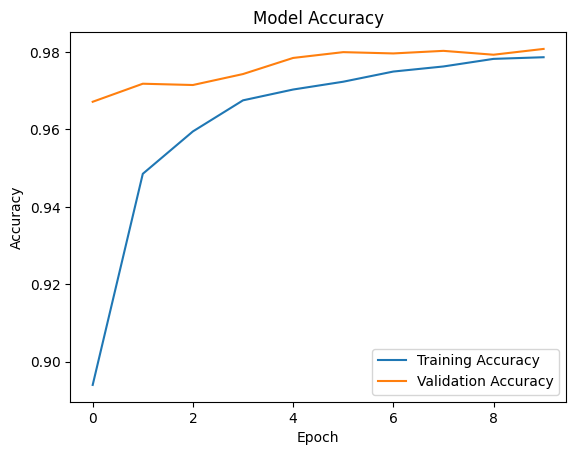

In [125]:
# Plot Accuracy
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

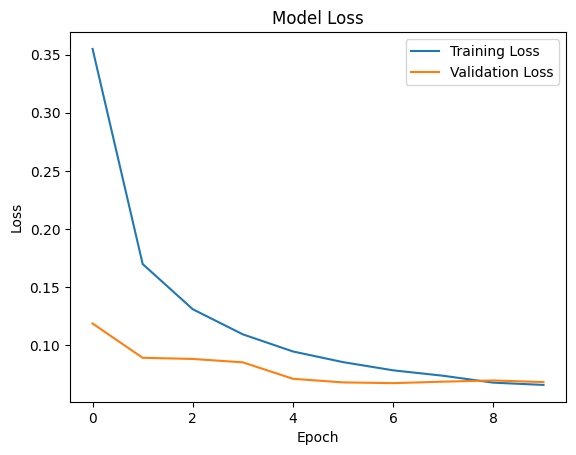

In [126]:
# Plot Loss
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()

In [127]:
model.save("../models/mnist_ann_model.keras")